# 5a: Histogram Stretching

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

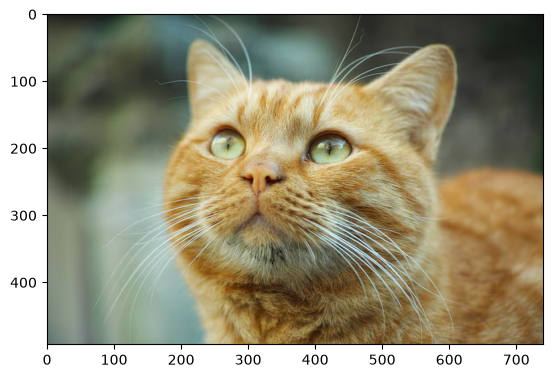

In [2]:
img = cv2.imread("images/image3.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

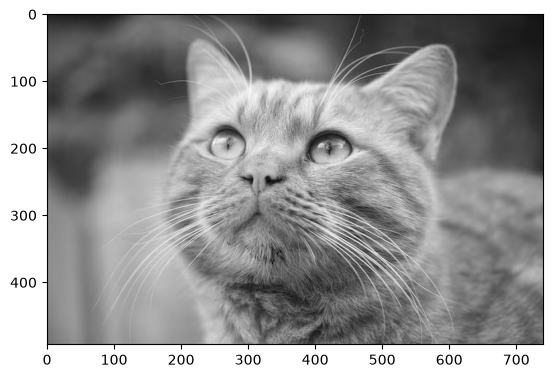

In [3]:
img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.imshow(img, cmap = "gray")
plt.show()

In [4]:
h, w = img.shape
print(f"height = {h},  width = {w}")

height = 493,  width = 740


In [5]:
r_min = float(img.min())
r_max = float(img.max())
s_min, s_max = 0.0, 255.0
print(f"r_min = {r_min}, r_max = {r_max}")
print(f"s_min = {s_min}, s_max = {s_max}")

r_min = 1.0, r_max = 248.0
s_min = 0.0, s_max = 255.0


`s = (((smax-smin)/(rmax-rmin)) * (r-rmin)) +smin`

/var/folders/0d/2kwkrk3j5j373ss9sbf8sd6m0000gn/T/ipykernel_54077/3238612677.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.ravel(), 256, [0, 256], color='blue', alpha=0.7)


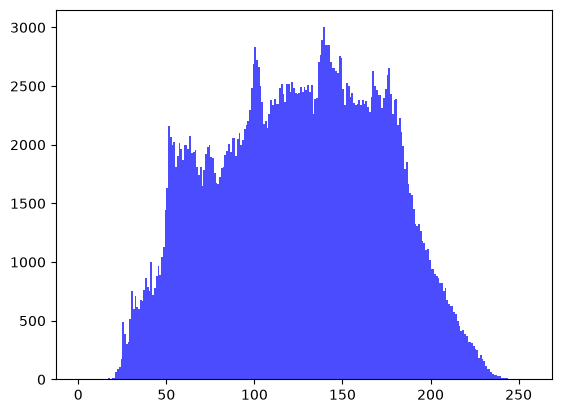

In [6]:
plt.hist(img.ravel(), 256, [0, 256], color='blue', alpha=0.7)
plt.show()

In [7]:
img.shape

(493, 740)

In [8]:
def hist_stretch(img, rmin, rmax, smin,smax):
    h, w = img.shape
    out = img.copy()
    for i in range(h):
        for j in range(w):
            r = img[i,j]
            out[i,j] = (((smax-smin)/(rmax-rmin)) * (r-rmin)) + smin

    return out

In [9]:
stretched_img = hist_stretch(img, r_min, r_max, s_min, s_max)


/var/folders/0d/2kwkrk3j5j373ss9sbf8sd6m0000gn/T/ipykernel_54077/3485307259.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(stretched_img.ravel(), 256, [0, 256], color='blue', alpha=0.7)


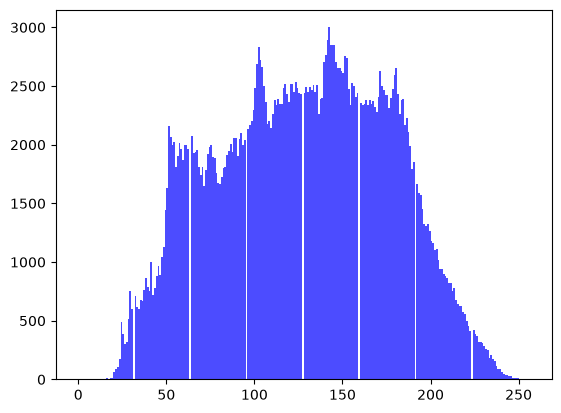

In [10]:
plt.hist(stretched_img.ravel(), 256, [0, 256], color='blue', alpha=0.7)
plt.show()

In [11]:
r_new_min = float(stretched_img.min())
r_new_max = float(stretched_img.max())

print(f"r_new_min = {r_new_min}, r_new_max = {r_new_max}")

r_new_min = 0.0, r_new_max = 255.0


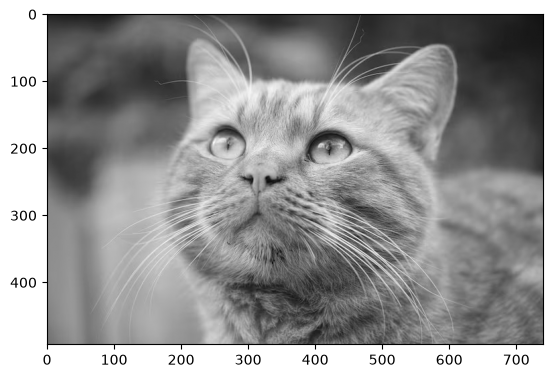

In [12]:
plt.imshow(stretched_img, cmap = "gray")
plt.show()

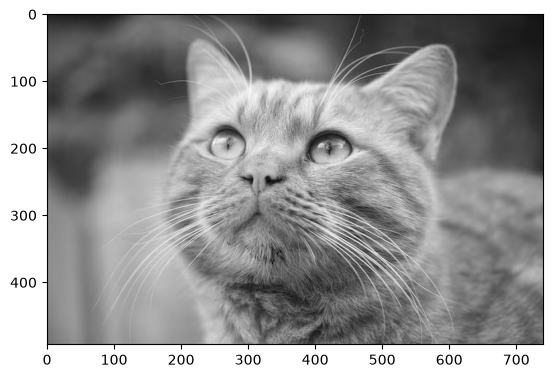

In [13]:
plt.imshow(img, cmap = "gray")
plt.show()

In [14]:
stretched_img

array([[ 35,  35,  34, ...,  20,  20,  20],
       [ 36,  36,  35, ...,  20,  20,  20],
       [ 37,  37,  37, ...,  20,  20,  20],
       ...,
       [111, 111, 112, ..., 104, 108, 111],
       [111, 111, 112, ..., 107, 111, 113],
       [111, 111, 112, ..., 107, 110, 111]], shape=(493, 740), dtype=uint8)

In [15]:
img

array([[ 35,  35,  34, ...,  21,  21,  21],
       [ 36,  36,  35, ...,  21,  21,  21],
       [ 37,  37,  37, ...,  21,  21,  21],
       ...,
       [109, 109, 110, ..., 102, 106, 109],
       [109, 109, 110, ..., 105, 109, 111],
       [109, 109, 110, ..., 105, 108, 109]], shape=(493, 740), dtype=uint8)

In [16]:
def plot_hist(img):
    counts = np.bincount(img.ravel().astype(int), minlength=256)
    bins = np.arange(256)
    plt.bar(bins, counts, color='blue', alpha=0.7, width=1.0)
    plt.xlim([0, 255])
    plt.show()

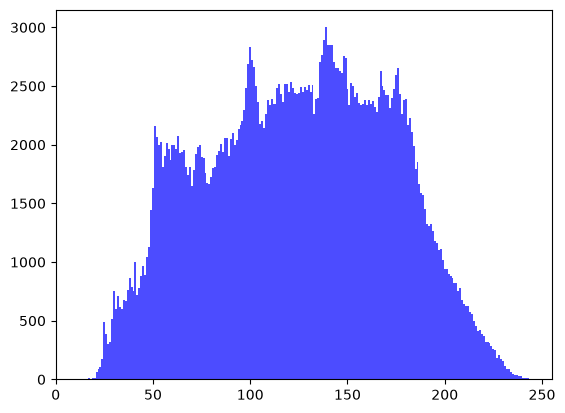

In [17]:
plot_hist(img)

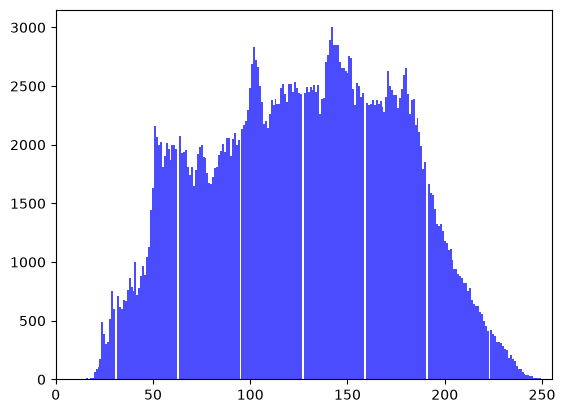

In [18]:
plot_hist(stretched_img)

# 5b: Histogram Equalization

In [19]:
def get_frequency(img):
    counts = np.bincount(img.ravel().astype(int), minlength=256)
    return counts

In [20]:
def hist_equalization(img):
    h, w = img.shape
    out = img.copy()
    freq = get_frequency(img)
    pdf = freq / (h * w)
    cdf = np.cumsum(pdf)
    round_cdf = np.round(cdf * 255).astype(np.uint8)

    for i in range(h):
        for j in range(w):
            out[i, j] = round_cdf[img[i, j]]

    return out

In [21]:
equalized_img = hist_equalization(img)

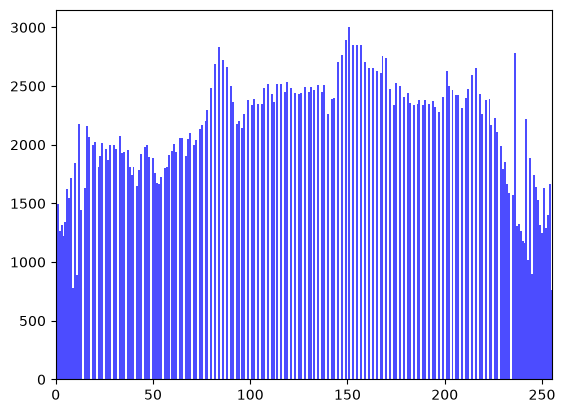

In [22]:
plot_hist(equalized_img)

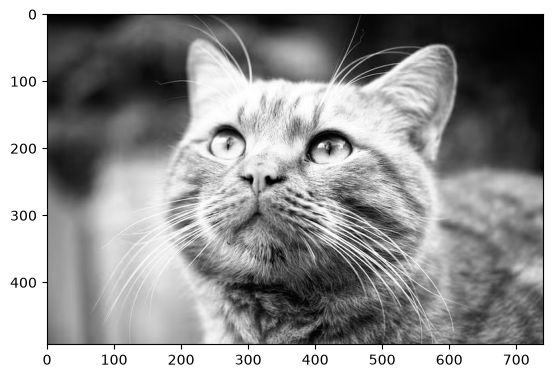

In [23]:
plt.imshow(equalized_img, cmap = "gray")

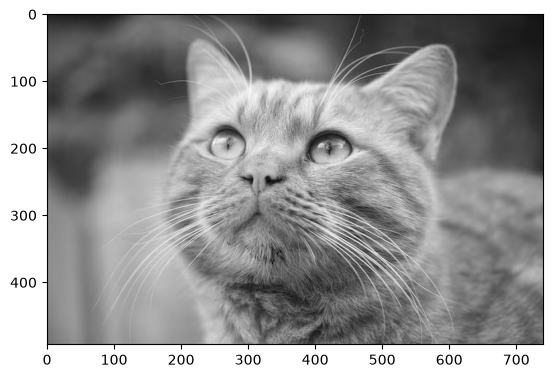

In [24]:
plt.imshow(img, cmap = "gray")
plt.show()